# Feature Engineering Lab 03
# Handling Missing Values (Industry Edition)

## Learning Outcomes

By the end of this lab you will:

- Understand why missing values occur
- Differentiate MCAR, MAR and MNAR
- Perform numerical and categorical imputation
- Create missing indicator features
- Compare business impact before and after imputation

---
## Why?

A machine learning model cannot learn from blank cells. The way we handle missing data directly affects model quality and business decisions.


# Industry Case Study

## Bank Loan Approval System

A retail bank wants to predict whether a customer will repay a loan.

Data comes from:

- Online application forms
- Credit bureau
- HR payroll
- Relationship manager

Unfortunately, some information is missing.

Examples:

- Customer skipped income.
- Credit bureau API failed.
- City was not captured.
- Salary documents were pending.

**Question:** Should we delete these customers?

Usually **No**. We must intelligently handle missing values.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer

df=pd.read_csv("C:\\Projects\\PycharmProjects\\GitRepo\\FeatureEnggAndMLOPs\\datasets\\customer_loan_missing_values.csv")
df.head()

,CustomerID,Age,MonthlyIncome,ExperienceYears,City,Occupation,CreditScore,LoanApproved
0,1,41.0,NaN,16,Mumbai,Engineer,824.0,1
1,2,NaN,138677.0,1,Mumbai,Teacher,596.0,0
2,3,NaN,41216.0,32,Hyderabad,Analyst,575.0,0
3,4,30.0,166737.0,8,Hyderabad,Doctor,836.0,1
4,5,44.0,50540.0,18,Mumbai,Manager,580.0,0


# Step 1 – Explore Missing Values

Before fixing anything, always measure the problem.


In [5]:
df.info()

print("\nMissing Values")
print(df.isnull().sum())

missing_percentage=(df.isnull().sum()/len(df)*100).round(2)
print("\nMissing Percentage")
print(missing_percentage)

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       200 non-null    int64  
 1   Age              182 non-null    float64
 2   MonthlyIncome    173 non-null    float64
 3   ExperienceYears  200 non-null    int64  
 4   City             187 non-null    str    
 5   Occupation       200 non-null    str    
 6   CreditScore      174 non-null    float64
 7   LoanApproved     200 non-null    int64  
dtypes: float64(3), int64(3), str(2)
memory usage: 12.6 KB

Missing Values
CustomerID          0
Age                18
MonthlyIncome      27
ExperienceYears     0
City               13
Occupation          0
CreditScore        26
LoanApproved        0
dtype: int64

Missing Percentage
CustomerID          0.0
Age                 9.0
MonthlyIncome      13.5
ExperienceYears     0.0
City                6.5
Occupation          0.0
CreditScore        

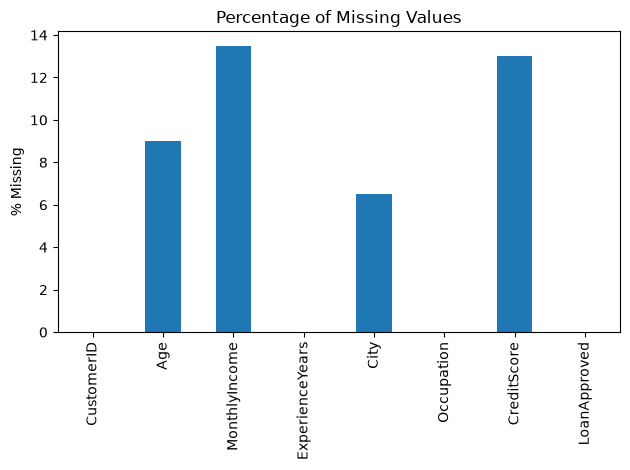

In [8]:
missing_percentage.plot(kind="bar")
plt.title("Percentage of Missing Values")
plt.ylabel("% Missing")
plt.tight_layout()
plt.show()

# Understanding MCAR, MAR and MNAR

### MCAR
Data missing completely at random.

Example:
A server crashed for 5 minutes.

---

### MAR
Missing depends on another variable.

Example:
High-income customers often skip income disclosure.

---

### MNAR
Missing depends on the missing value itself.

Example:
Customers with very low credit scores intentionally hide them.


# Manual Exercise

Suppose you are a Data Scientist.

| Feature | Missing? | What would you do? |
|----------|----------|--------------------|
| Age | Yes | ? |
| MonthlyIncome | Yes | ? |
| City | Yes | ? |
| CreditScore | Yes | ? |

Discuss in groups before coding.


In [7]:
numeric=["Age","MonthlyIncome","CreditScore"]

median_imp=SimpleImputer(strategy="median")
df[numeric]=median_imp.fit_transform(df[numeric])

cat=["City"]
mode_imp=SimpleImputer(strategy="most_frequent")
df[cat]=mode_imp.fit_transform(df[cat])

print(df.isnull().sum())

CustomerID         0
Age                0
MonthlyIncome      0
ExperienceYears    0
City               0
Occupation         0
CreditScore        0
LoanApproved       0
dtype: int64


# Missing Indicator Features

Sometimes the fact that a value was missing is itself useful.

Example:

IncomeMissing = 1 if income was missing else 0

Banks often use such indicators because missing income can correlate with customer behaviour.


In [10]:
df2=pd.read_csv("C:\\Projects\\PycharmProjects\\GitRepo\\FeatureEnggAndMLOPs\\datasets\\customer_loan_missing_values.csv")

df2["IncomeMissing"]=df2["MonthlyIncome"].isnull().astype(int)

print(df2[["MonthlyIncome","IncomeMissing"]].head(10))

   MonthlyIncome  IncomeMissing
0            NaN              1
1       138677.0              0
2        41216.0              0
3       166737.0              0
4        50540.0              0
5       178501.0              0
6            NaN              1
7       135545.0              0
8       177016.0              0
9       176505.0              0


# Best Practices

- Measure missingness before cleaning.
- Never blindly delete rows.
- Median is robust for skewed numerical data.
- Mode is suitable for categorical variables.
- Consider domain knowledge before choosing an imputation strategy.
- Track missing indicators when appropriate.

# Interview Questions

1. Difference between MCAR, MAR and MNAR?
2. Mean vs Median imputation?
3. When should rows be removed?
4. Why create missing indicator features?
5. What is data leakage during imputation?

# Assignment

1. Compare mean and median imputation for MonthlyIncome.
2. Create a bar chart of missing percentages.
3. Try dropping rows with missing values and compare remaining dataset size.
4. Research KNN Imputer and apply it to Age and CreditScore.
